动态中断&静态中断

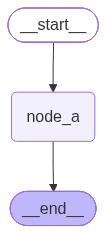

{'__interrupt__': [Interrupt(value='请输入您的姓名：', id='ba93c134893ec7d26ce27078adac5169')]}


In [22]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.constants import START, END
from langgraph.graph import StateGraph, MessagesState
from typing import TypedDict, Required, Literal

from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display


class OverAllState(TypedDict):
    username: str
    age: int


def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名：")
    return {
        "username": username
    }


# builder
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)
# checkpoint
graph = builder.compile(checkpointer=InMemorySaver())
display(graph)

cfg = {
    "configurable": {
        "thread_id": "123"
    }
}

response = graph.invoke({}, config=cfg)
print(response)

In [23]:
prompt = response['__interrupt__'][0].value
username = input(prompt)
resume_res = graph.invoke(Command(resume=username), config=cfg)
print(resume_res)

{'username': '11'}


### 多个并行中断

In [24]:
def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄：")
    return {
        "age": age
    }


builder2 = StateGraph(state_schema=OverAllState)
builder2.add_node("node_b", node_b)
builder2.add_node("node_a", node_a)
builder2.add_edge(START, "node_b")
builder2.add_edge(START, "node_a")
builder2.add_edge("node_b", END)
builder2.add_edge("node_a", END)
graph2 = builder2.compile(checkpointer=InMemorySaver())
cfg2 = {
    "configurable": {
        "thread_id": "xiaoxu"
    }
}
response = graph2.invoke({}, config=cfg2)
print(response)
resume_map = {}
if response['__interrupt__']:
    for i in response['__interrupt__']:
        user_input = input(i.value)
        resume_map[i.id] = user_input

print(graph2.invoke(Command(resume=resume_map), config=cfg2))

{'__interrupt__': [Interrupt(value='请输入您的年龄：', id='7ff82f5b4b228b5fd56246fb195e5535'), Interrupt(value='请输入您的姓名：', id='fdb1dee0746b805771d2cb3e3678a4d3')]}
{'username': '11', 'age': '11'}


### 审批模式

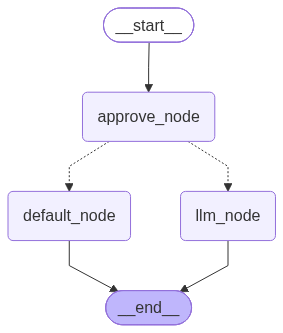

{'messages': [], 'topic': '月亮', '__interrupt__': [Interrupt(value='是否同意调用模型？(y/n)', id='60b3ba8f687151d6d539669ab843a43c')]}


In [30]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv(override=True)
model = ChatDeepSeek(model="deepseek-flash", extra_body={
    "thinking": {
        "type": "disabled"
    }
})


# state
class CustomerState(MessagesState):
    topic: Required[str]
    poem: str
    is_approved: bool


def approve_node(state: CustomerState) -> Command[Literal["llm_node", "default_node"]]:
    is_approved = interrupt("是否同意调用模型？(y/n)")
    goto = "llm_node" if is_approved else "default_node"
    return Command(
        goto=goto,
        update={
            "is_approved": is_approved
        }
    )


def llm_node(state: CustomerState) -> CustomerState:
    topic = state["topic"]
    res = model.invoke([
        HumanMessage(content=f"帮我写一首关于{topic}的七言绝句，只需要诗句不需要赏析。")
    ])
    return {
        "messages": [res]
    }


def default_node(state: CustomerState) -> CustomerState:
    return {
        "messages": [AIMessage(content="请求被拒绝")]
    }


builder3 = StateGraph(state_schema=CustomerState)
builder3.add_node("approve_node", approve_node)
builder3.add_node("llm_node", llm_node)
builder3.add_node("default_node", default_node)

builder3.add_edge(START, "approve_node")
builder3.add_edge("llm_node", END)
builder3.add_edge("default_node", END)
cfg3 = {
    "configurable": {
        "thread_id": "abc"
    }
}
graph3 = builder3.compile(checkpointer=InMemorySaver())
display(graph3)
# 触发中断
response3 = graph3.invoke({"topic":"月亮"}, config=cfg3)
print(response3)

In [31]:
user_map = {}
for i in response3["__interrupt__"]:
    user_input = input(f"{i.value}").strip().lower() == 'y'
    user_map[i.id] = user_input

response4 = graph3.invoke(Command(resume=user_map), config=cfg3)
print(response4["messages"][-1])

content='请求被拒绝' additional_kwargs={} response_metadata={} id='d9dd6238-80db-4986-adeb-9cd80e2d74c4' tool_calls=[] invalid_tool_calls=[]
